## Homography Crop

This code given an image -thermal baby image- and a its corresponding visible counterpart by selecting points in the image is able to craft a homography matrix and transform all visible images in a folder accordingly. This notebook specifically was made to convert those images to 480 × 640.

### **Disclaimer: This code should be executed with the following things in mind.**
- A good homography matrix, the best possible one, compute as many points as possible, based on two extremely clear images.
- It should be executed twice, one for each camera, separating images in folders depending on the camera.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

In [2]:
# Provide file paths
# !!!! This are the images that will be used for the homography matrix creation
# We should work twice, one per thermal camera

thermal_path = "HM20240814214018 copy.jpeg" # for the thermal image for the homography matrix
visible_path = "HM20240814214018_VIS copy.jpeg" # for the visible image for the homography matrix
matrix_path = "homography_matrix.txt" # to save the homography matrix (if good)

visible_folder = "visible" # for the visible images, to warp/transform
output_folder = "aligned" # for the aligned images, to save the warped images

### Point selection

In [3]:
# Load images
visible_img = cv2.imread(visible_path)
thermal_img = cv2.imread(thermal_path)
print("Visible image shape:", visible_img.shape)
print("Thermal image shape:", thermal_img.shape)
visible_pts = []
thermal_pts = []

Visible image shape: (3264, 2448, 3)
Thermal image shape: (640, 480, 3)


In [4]:
import cv2
import numpy as np

# Resize factor for display (visual only)
target_height = 600
scale_visible = target_height / visible_img.shape[0]
scale_thermal = target_height / thermal_img.shape[0]

# Resize for display only
visible_resized = cv2.resize(visible_img, (int(visible_img.shape[1] * scale_visible), target_height))
thermal_resized = cv2.resize(thermal_img, (int(thermal_img.shape[1] * scale_thermal), target_height))

# Combine for side-by-side view
combined_img = np.hstack((visible_resized, thermal_resized))
combined_clone = combined_img.copy()
split_x = visible_resized.shape[1]

# Containers for original-scale points
visible_pts = []
thermal_pts = []

# Click handler
def click_points_combined(event, x, y, flags, param):
    img, v_pts, t_pts, split, scale_v, scale_t = param
    if event == cv2.EVENT_LBUTTONDOWN:
        if x < split:
            # Convert back to original coordinates
            orig_x = int(x / scale_v)
            orig_y = int(y / scale_v)
            v_pts.append([orig_x, orig_y])
            cv2.circle(img, (x, y), 5, (0, 255, 0), -1)
            cv2.putText(img, f'V{len(v_pts)}', (x+5, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
        else:
            adj_x = x - split
            orig_x = int(adj_x / scale_t)
            orig_y = int(y / scale_t)
            t_pts.append([orig_x, orig_y])
            cv2.circle(img, (x, y), 5, (255, 0, 0), -1)
            cv2.putText(img, f'T{len(t_pts)}', (x+5, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)
        cv2.imshow("Click Keypoints on Both Images", img)

# Display window
cv2.imshow("Click Keypoints on Both Images", combined_clone)
cv2.setMouseCallback("Click Keypoints on Both Images", click_points_combined, 
                     [combined_clone, visible_pts, thermal_pts, split_x, scale_visible, scale_thermal])
cv2.waitKey(0)
cv2.destroyAllWindows()

# Convert to numpy arrays
src_pts = np.array(visible_pts, dtype=np.float32)
dst_pts = np.array(thermal_pts, dtype=np.float32)

# Compute homography using original-resolution points
if len(src_pts) >= 4 and len(dst_pts) >= 4:
    H, status = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC)
    print("Homography Matrix (from visible to thermal):\n", H)
else:
    print("Need at least 4 points on each image to compute homography.")

Homography Matrix (from visible to thermal):
 [[ 2.13743709e-01  3.40874742e-03 -6.18438110e+01]
 [-1.75101756e-02  2.71633044e-01 -8.90912446e+01]
 [-9.51577308e-05  3.60607466e-05  1.00000000e+00]]


In [5]:
print(H)
print(H.shape)
print(H.ndim)   # Output: number of dimensions (e.g., 1 for 1D, 2 for 2D)
print(isinstance(H, np.ndarray))  # Output: True if it's a NumPy array
print(H.dtype)

[[ 2.13743709e-01  3.40874742e-03 -6.18438110e+01]
 [-1.75101756e-02  2.71633044e-01 -8.90912446e+01]
 [-9.51577308e-05  3.60607466e-05  1.00000000e+00]]
(3, 3)
2
True
float64


### Image showcase sanity check

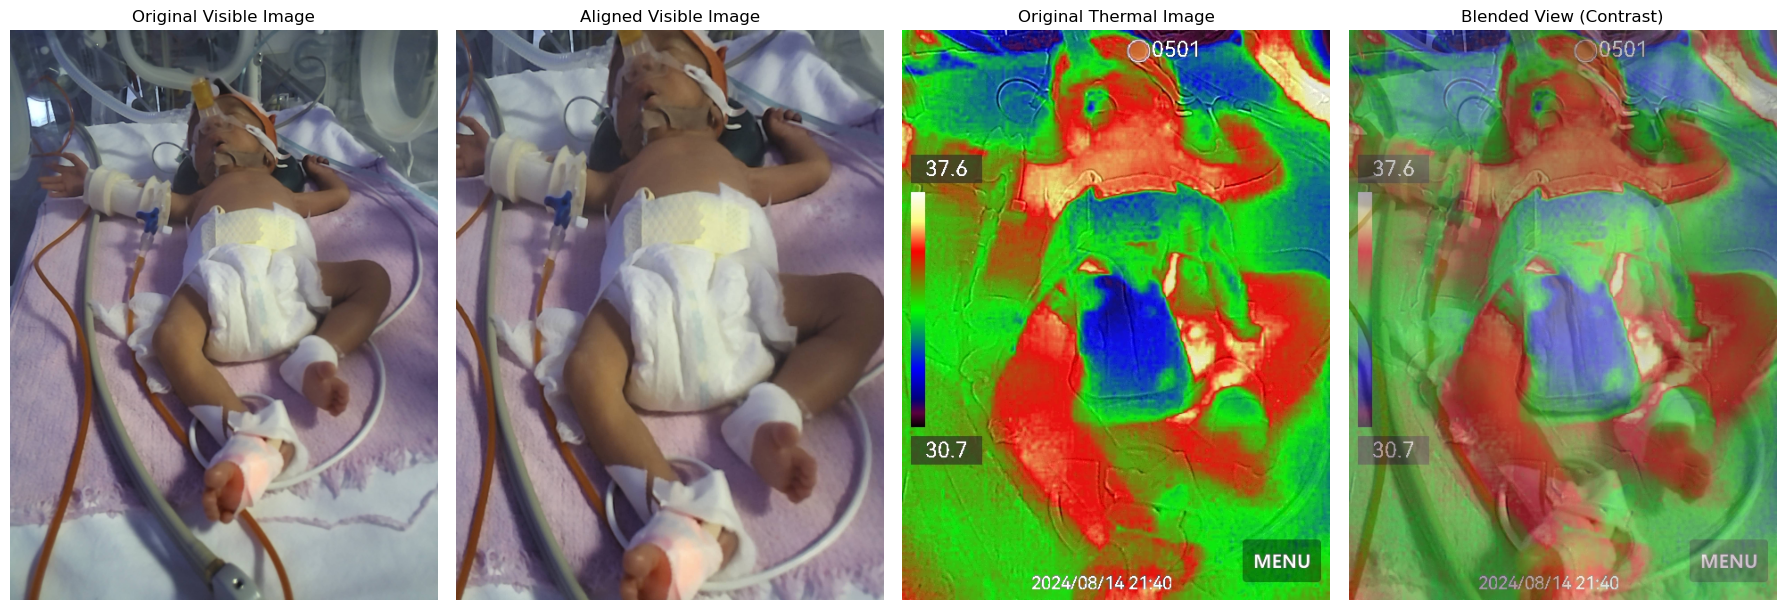

In [20]:
import matplotlib.pyplot as plt

if H is not None:
    # Warp the visible image to align with thermal image
    aligned_visible = cv2.warpPerspective(visible_img, H, (thermal_img.shape[1], thermal_img.shape[0]))

    # Convert BGR to RGB for matplotlib
    aligned_rgb = cv2.cvtColor(aligned_visible, cv2.COLOR_BGR2RGB)
    thermal_rgb = cv2.cvtColor(thermal_img, cv2.COLOR_BGR2RGB)

    # Optional: Blend images for visual contrast
    blend = cv2.addWeighted(aligned_rgb, 0.5, thermal_rgb, 0.5, 0)

    # Display all
    fig, axes = plt.subplots(1, 4, figsize=(18, 6))
    axes[0].imshow(cv2.cvtColor(visible_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Visible Image")
    axes[1].imshow(aligned_rgb)
    axes[1].set_title("Aligned Visible Image")
    axes[2].imshow(thermal_rgb)
    axes[2].set_title("Original Thermal Image")
    axes[3].imshow(blend)
    axes[3].set_title("Blended View (Contrast)")

    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Homography not computed.")


### Saving the homography matrix as a txt to reuse if good, just a failsafe.

In [22]:
def save_homography_matrix(H, filename):
    """
    Saves the homography matrix H to a .txt file.

    Parameters:
        H (np.ndarray): 3x3 Homography matrix.
        filename (str): Output text file path.

    """
    np.savetxt(filename, H, fmt='%.8f', delimiter=',')
    print(f"Homography matrix saved to {filename}")

def load_homography_matrix(filename):
    """
    Loads a 3x3 homography matrix from a .txt file.

    Parameters:
        filename (str): Path to the text file containing the matrix.

    Returns:
        np.ndarray: 3x3 Homography matrix.
    """
    H = np.loadtxt(filename, delimiter=',')
    if H.shape != (3, 3):
        raise ValueError(f"Invalid matrix shape {H.shape}. Expected 3x3.")
    print(f"Homography matrix loaded from {filename}")
    return H


In [ ]:
# Save the homography matrix to a text file
save_homography_matrix(H, matrix_path)

In [ ]:
# CHECKS

# Load the homography matrix from the text file
print("OG Matrix:\n",H)
loaded_H = load_homography_matrix(matrix_path)
print("Loaded Homography Matrix:\n", loaded_H)
# Check if the loaded matrix is the same as the original
if np.allclose(H, loaded_H):
    print("Loaded homography matrix matches the original.")

print(H.shape)
print(H.ndim)   # Output: number of dimensions (e.g., 1 for 1D, 2 for 2D)
print(isinstance(H, np.ndarray))  # Output: True if it's a NumPy array
print(H.dtype)
print(loaded_H.shape)
print(loaded_H.ndim)   # Output: number of dimensions (e.g., 1 for 1D, 2 for 2D)
print(isinstance(loaded_H, np.ndarray))  # Output: True if it's a NumPy array
print(loaded_H.dtype)

OG Matrix:
 [[ 2.13743709e-01  3.40874742e-03 -6.18438110e+01]
 [-1.75101756e-02  2.71633044e-01 -8.90912446e+01]
 [-9.51577308e-05  3.60607466e-05  1.00000000e+00]]
Homography matrix loaded from homography_matrix.txt
Loaded Homography Matrix:
 [[ 2.13743710e-01  3.40875000e-03 -6.18438110e+01]
 [-1.75101800e-02  2.71633040e-01 -8.90912446e+01]
 [-9.51600000e-05  3.60600000e-05  1.00000000e+00]]
Loaded homography matrix matches the original.
(3, 3)
2
True
float64
(3, 3)
2
True
float64


### Given homography matrix: warp images from input to output folder

In [9]:
def warp_images_from_folder(visible_folder, H, target_shape, output_dir, extensions=[".jpg", ".png", ".jpeg"]):
    """
    Applies a homography matrix to all images in a folder.

    Parameters:
        visible_folder (str): Path to the folder with visible images.
        H (np.ndarray): 3x3 Homography matrix.
        target_shape (tuple): Shape (height, width) to warp images to (from the thermal image).
        output_dir (str): Directory to save warped images.
        extensions (list): List of valid image file extensions.

    Returns:
        None
    """
    os.makedirs(output_dir, exist_ok=True)

    # Get all image files in the folder
    image_paths = []
    for ext in extensions:
        image_paths.extend(glob(os.path.join(visible_folder, f"*{ext}")))

    if not image_paths:
        print("No images found in the folder.")
        return

    for image_path in image_paths:
        img = cv2.imread(image_path)
        if img is None:
            print(f"Warning: Could not read {image_path}")
            continue

        warped_img = cv2.warpPerspective(img, H, (target_shape[1], target_shape[0]))
        filename = os.path.basename(image_path)
        save_path = os.path.join(output_dir, f"aligned_{filename}")
        cv2.imwrite(save_path, warped_img)
        print(f"Saved aligned image to {save_path}")


In [33]:

target_shape = thermal_img.shape[:2]  # (height, width)
print("Target shape:", target_shape)
print(H)
warp_images_from_folder(visible_folder, H, (640, 480), output_folder)

Target shape: (640, 480)
[[ 2.13743709e-01  3.40874742e-03 -6.18438110e+01]
 [-1.75101756e-02  2.71633044e-01 -8.90912446e+01]
 [-9.51577308e-05  3.60607466e-05  1.00000000e+00]]
Saved aligned image to aligned/aligned_HM20240814214018_VIS.jpeg
Saved aligned image to aligned/aligned_HM20240814213403_VIS.jpeg
Saved aligned image to aligned/aligned_HM20240814213710_VIS.jpeg
Saved aligned image to aligned/aligned_HM20240814213507_VIS.jpeg
Saved aligned image to aligned/aligned_HM20240814213609_VIS.jpeg
Saved aligned image to aligned/aligned_HM20240814213916_VIS.jpeg
Saved aligned image to aligned/aligned_HM20240814213814_VIS.jpeg
Saved aligned image to aligned/aligned_HM20240814214120_VIS.jpeg


In [17]:
"""aligned_test = cv2.imread("aligned/aligned_HM20240814213403_VIS.jpeg")
print("aligned shape", aligned_test.shape) """

aligned shape (640, 480, 3)
